# Ch17 位置控制迴路(Position-Control Loops)

**對應原書**:Chapter 17
**軟體替代**:ModelQ 位置迴路範例 → 串級(P 位置 + PI 速度)與單迴路 PID 對決

## 學習目標
1. 實作工業標準的**串級位置迴路**:P 位置環包 PI 速度環。
2. 理解串級的殺手級優點:**速度極限就是一個 clip**,飽和行為乾淨可控。
3. 比較單迴路 PID:性能可以接近,但約束處理與調機體驗差很多。

## 結構
```
pos_ref ─►(+)─ kp_pos ─►[clip ±v_max]─►(+)─►[PI]─►[clip ±u_max]─► plant ─► pos
           ▲-                           ▲-                    │
           └────────────────────────────┴────────w────────────┘
```

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

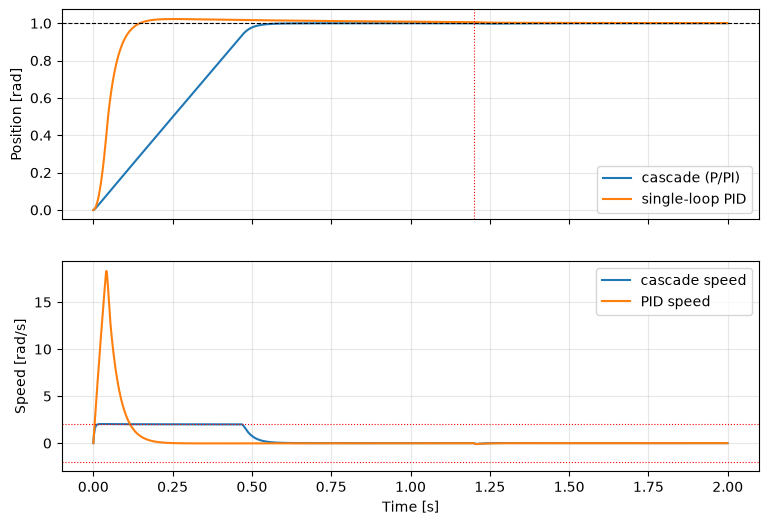

串級:max|w|=2.03(極限 2.0),擾動偏移 2.01 mrad
PID :max|w|=18.30(未受控!),擾動偏移 6.27 mrad


In [2]:
J, b = 0.002, 0.01
fs = 1000.0
dt = 1 / fs
n = int(2.0 / dt)
t = np.arange(n) * dt
V_MAX, U_MAX = 2.0, 1.0                     # 速度極限 2 rad/s、轉矩極限 1 Nm
DIST_T = 1.2                                 # t=1.2 s 加入 0.05 Nm 負載

def run_cascade(step=1.0, kp_pos=30.0):
    plant = MotorPlant(J=J, b=b, dt=dt)
    vel = DiscretePID(0.5, 5.0, dt=dt, out_min=-U_MAX, out_max=U_MAX)
    pos_log, w_log = np.empty(n), np.empty(n)
    for k in range(n):
        pos_log[k], w_log[k] = plant.pos, plant.w
        v_cmd = np.clip(kp_pos * (step - plant.pos), -V_MAX, V_MAX)
        u = vel.step(v_cmd - plant.w)
        plant.step(u, t_dist=0.05 if t[k] >= DIST_T else 0.0)
    return pos_log, w_log

def run_pid(step=1.0):
    plant = MotorPlant(J=J, b=b, dt=dt)
    c = DiscretePID(15.0, 20.0, 0.5, dt=dt, dfilt_hz=100, out_min=-U_MAX, out_max=U_MAX)
    pos_log, w_log = np.empty(n), np.empty(n)
    for k in range(n):
        pos_log[k], w_log[k] = plant.pos, plant.w
        u = c.step(step - plant.pos)
        plant.step(u, t_dist=0.05 if t[k] >= DIST_T else 0.0)
    return pos_log, w_log

pos_c, w_c = run_cascade()
pos_p, w_p = run_pid()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax1.plot(t, pos_c, label='cascade (P/PI)')
ax1.plot(t, pos_p, label='single-loop PID')
ax1.axhline(1, color='k', ls='--', lw=0.8); ax1.axvline(DIST_T, color='r', ls=':', lw=0.8)
ax1.set_ylabel('Position [rad]'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(t, w_c, label='cascade speed')
ax2.plot(t, w_p, label='PID speed')
ax2.axhline(V_MAX, color='r', ls=':', lw=0.8); ax2.axhline(-V_MAX, color='r', ls=':', lw=0.8)
ax2.set_ylabel('Speed [rad/s]'); ax2.set_xlabel('Time [s]'); ax2.legend(); ax2.grid(alpha=0.3)
plt.show()

dev_c = float(np.max(np.abs(1 - pos_c[int(DIST_T/dt):])))
dev_p = float(np.max(np.abs(1 - pos_p[int(DIST_T/dt):])))
print(f'串級:max|w|={np.abs(w_c).max():.2f}(極限 {V_MAX}),擾動偏移 {dev_c*1000:.2f} mrad')
print(f'PID :max|w|={np.abs(w_p).max():.2f}(未受控!),擾動偏移 {dev_p*1000:.2f} mrad')

串級的速度波形是**梯形**:等速段速度精確貼著 V_MAX —— 因為速度極限就是位置環輸出的 clip。
單迴路 PID 沒有「速度」這個中間變數可以限制,大步階時速度衝到哪算哪。

## 追隨誤差與 kv 增益

等速運動時,P 位置環的追隨誤差 = $v / k_{p,pos}$(kv 增益的由來)。

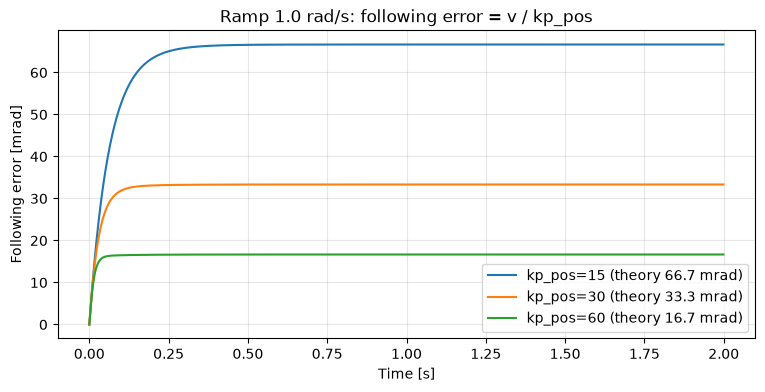

kp_pos=15: 量測 66.67 mrad,理論 66.67 mrad
kp_pos=30: 量測 33.33 mrad,理論 33.33 mrad
kp_pos=60: 量測 16.67 mrad,理論 16.67 mrad


In [3]:
# 等速段追隨誤差驗證:用斜坡命令
ramp_v = 1.0                                 # 1 rad/s 斜坡
def run_ramp(kp_pos):
    plant = MotorPlant(J=J, b=b, dt=dt)
    vel = DiscretePID(0.5, 5.0, dt=dt, out_min=-U_MAX, out_max=U_MAX)
    err = np.empty(n)
    for k in range(n):
        ref = ramp_v * t[k]
        err[k] = ref - plant.pos
        v_cmd = np.clip(kp_pos * err[k], -V_MAX, V_MAX)
        plant.step(vel.step(v_cmd - plant.w))
    return err

ferr = {}
plt.figure(figsize=(9, 4))
for kp_pos in [15.0, 30.0, 60.0]:
    err = run_ramp(kp_pos)
    ferr[kp_pos] = float(np.mean(err[int(1.0/dt):]))
    plt.plot(t, err * 1000, label=f'kp_pos={kp_pos:.0f} (theory {ramp_v/kp_pos*1000:.1f} mrad)')
plt.xlabel('Time [s]'); plt.ylabel('Following error [mrad]'); plt.legend(); plt.grid(alpha=0.3)
plt.title(f'Ramp {ramp_v} rad/s: following error = v / kp_pos')
plt.show()
for kp_pos, e in ferr.items():
    print(f'kp_pos={kp_pos:.0f}: 量測 {e*1000:.2f} mrad,理論 {ramp_v/kp_pos*1000:.2f} mrad')

In [4]:
# ✅ 驗證
assert np.abs(w_c).max() <= V_MAX * 1.05                  # 串級尊重速度極限
assert np.abs(w_p).max() > 3 * V_MAX                      # PID 無速度概念
assert float(pos_c.max()) < 1.005                         # 串級無 overshoot(梯形到位)
assert abs(pos_c[-1] - 1) < 1e-3 and abs(pos_p[-1] - 1) < 5e-3
assert dev_c < dev_p                                      # 串級剛性較好(內環先擋)
for kp_pos, e in ferr.items():
    assert abs(e - ramp_v / kp_pos) / (ramp_v / kp_pos) < 0.15   # 追隨誤差 = v/kv
print('Ch17 驗證通過 ✅')

Ch17 驗證通過 ✅


## 練習
1. 給串級加上第 8 章的速度前饋,斜坡追隨誤差降到多少?(這就是 kv + FF 的完整位置環)
2. kp_pos 掃到 120,梯形波形開始變形 —— 找出內外環頻寬比的下限(經驗:外環 ≤ 內環的 1/3~1/5)。
3. 把速度極限降到 0.5 rad/s,兩種架構的表現差距如何變化?
4. 用第 16 章的 two-mass 機台跑本章串級迴路,kp_pos 上限受什麼牽制?